In [1]:
import sys
import os
import warnings
import uuid

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

warnings.filterwarnings("ignore")

**LangGraph**

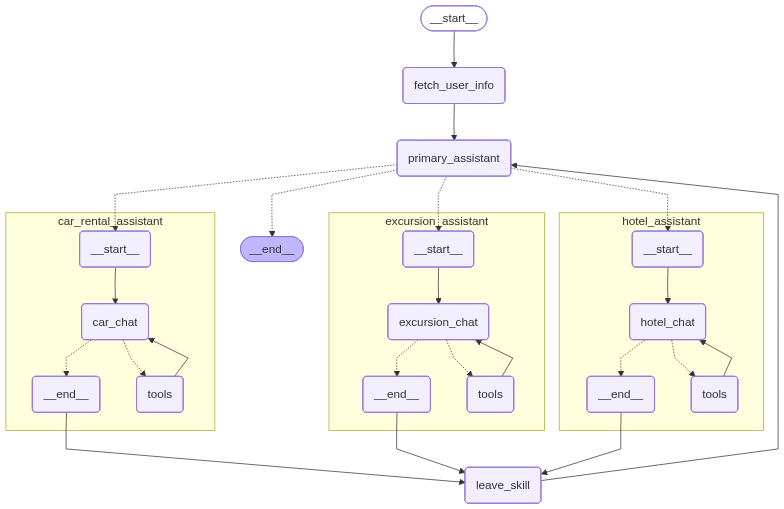

In [2]:
from agents.primary.agent import primary_graph
from IPython.display import Image, display

try:
    display(Image(primary_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [3]:
_printed = set()

def _print_event(event: dict, _printed: set, max_length=1000):
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)

In [4]:



tutorial_questions = [
    "Hi there, tôi muốn kiếm khách sạn tốt nhất ở Hà Nội."
]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    }
}

for question in tutorial_questions:
    events = primary_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Hi there, tôi muốn kiếm khách sạn tốt nhất ở Hà Nội.
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (6d3e3a5f-2221-4448-9816-d25a0830ed6c)
 Call ID: 6d3e3a5f-2221-4448-9816-d25a0830ed6c
  Args:
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 10 existing booking points in Qdrant.
⏳ Indexing 10 bookings...
 Successfully indexed 10 bookings to Qdrant.
 Qdrant semantic search: Found 3 results
================================== Ai Message ==================================

Ở Hà Nội, tôi tìm thấy một số khách sạn được đánh giá ca

In [4]:



tutorial_questions = [
    "Tìm kiếm khách sạn ở Đè Nẵng, rating cỡ 9.0, gia ca hạng sang.",
    "Tôi muốn kiếm xe có sức chứa 4 người ở Hanoi Drive Car Rental."
]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    }
}

for question in tutorial_questions:
    events = primary_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Tìm kiếm khách sạn ở Đè Nẵng, rating cỡ 9.0, gia ca hạng sang.
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (d1fa03fe-301c-4102-9b09-4cd45afa2291)
 Call ID: d1fa03fe-301c-4102-9b09-4cd45afa2291
  Args:
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 8 existing booking points in Qdrant.
⏳ Indexing 8 bookings...
 Successfully indexed 8 bookings to Qdrant.
 Qdrant semantic search: Found 1 results
================================== Ai Message ==================================

Tôi tìm thấy khách sạn InterContinental Danang Su

In [7]:



tutorial_questions = [
    "Tìm kiếm khách sạn ở Đè Nẵng, rating cỡ 9.0, gia ca hạng sang. Tôi muốn kiếm xe có sức chứa 4 người ở Hanoi Drive Car Rental.",
    
]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    }
}

for question in tutorial_questions:
    events = primary_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Tìm kiếm khách sạn ở Đè Nẵng, rating cỡ 9.0, gia ca hạng sang. Tôi muốn kiếm xe có sức chứa 4 người ở Hanoi Drive Car Rental.
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (a46a9af6-45d0-4513-8695-b2113ac10553)
 Call ID: a46a9af6-45d0-4513-8695-b2113ac10553
  Args:
 Qdrant semantic search: Found 1 results
================================== Ai Message ==================================

Tôi tìm thấy khách sạn InterContinental Danang Sun Peninsula ở Đà Nẵng, có rating 9.3 và thuộc hạng sang. Bạn có muốn đặt phòng ở đây không?
================================== Ai Message ==================================



Đối với yêu cầu thuê xe, tôi sẽ chuyển yêu cầu của bạn đến bộ phận chuyên trách về thuê xe.
Tool Calls:
  ToCarRentalAssistant (f50dfa8b-5ee9-453b-a6ec-02c4e4d389e4)
 Call ID: f50dfa8b-5ee9-453b-a6ec-02c4e4d389e4
  Args:
Resolved car_rent

In [8]:

tutorial_questions = [
    "Tìm kiếm khách sạn ở Đè Nẵng, rating cỡ 9.0, gia ca hạng sang. ",
    "Ban nhớ tôi nói gì không."
]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    }
}

for question in tutorial_questions:
    events = primary_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Tìm kiếm khách sạn ở Đè Nẵng, rating cỡ 9.0, gia ca hạng sang. 
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (4ac1a661-b155-42b2-afde-927dbb51e1cd)
 Call ID: 4ac1a661-b155-42b2-afde-927dbb51e1cd
  Args:
 Qdrant semantic search: Found 1 results
================================== Ai Message ==================================

Tôi tìm được khách sạn InterContinental Danang Sun Peninsula ở Đà Nẵng, có rating 9.3, thuộc hạng sang. Bạn có muốn đặt phòng ở đây không?
================================== Ai Message ==================================
================================ Human Message =================================

Ban nhớ tôi nói gì không.
================================== Ai Message ==================================

Vâng, tôi nhớ. Bạn đã yêu cầu tôi tìm kiếm khách sạn ở Đà Nẵng, với rating khoảng 9.0 và giá cả hạng sang. Tôi đã t

In [9]:

tutorial_questions = [
    "Tôi muốn đặt dạng phòng suit  từ 1/1/2026 đến 3/1/2026 ở khách sạn InterContinental Danang",
]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    }
}

for question in tutorial_questions:
    events = primary_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Tôi muốn đặt dạng phòng suit  từ 1/1/2026 đến 3/1/2026 ở khách sạn InterContinental Danang
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (af2ba1bc-c538-4f1e-8c05-3130dafd3e59)
 Call ID: af2ba1bc-c538-4f1e-8c05-3130dafd3e59
  Args:
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 9 existing booking points in Qdrant.
⏳ Indexing 10 bookings...
 Successfully indexed 10 bookings to Qdrant.
================================== Ai Message ==================================

Bạn đã đặt phòng suit tại khách sạn InterContinental Danang 

In [ ]:

tutorial_questions = [
    "Tìm kiếm khách sạn ở Đè Nẵng, rating cỡ 9.0, gia ca hạng sang. Tôi muốn tìm phòng có sức chứa 2 người ở khách sạn đó.",
]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    }
}

for question in tutorial_questions:
    events = primary_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

In [8]:

tutorial_questions = [
    "I want to book room hotel that has room id 1, checkin date = 15/8/2025, checkout date = 17/8/2025",

]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    }
}

for question in tutorial_questions:
    events = primary_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

I want to book room hotel that has room id 1, checkin date = 15/8/2025, checkout date = 17/8/2025
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (4eabe60c-8ee4-4b8a-bada-42fce9dd88f7)
 Call ID: 4eabe60c-8ee4-4b8a-bada-42fce9dd88f7
  Args:
    request: book room with room id 1
    checkout_date: 2025-08-17
    checkin_date: 2025-08-15
================================== Ai Message ==================================

I am sorry, room 1 is not available for the check-in date 15/8/2025 and check-out date 17/8/2025. It is already booked from 2025-08-15 to 2025-08-18. Please choose another room or another date.


Gemini produced an empty response. Continuing with empty message
Feedback: 


================================== Ai Message ==================================

I'm sorry, I'm not sure what you mean by "real output." The previous response indicated that room 1 is already booked for the dates you requested.

Would you like to try booking a different room, or perhaps different check-in and check-out dates?


In [9]:
tutorial_questions = [
    "I want to update hotel  booking id = 1, checkin date = 10/8/2025, checkout date = 13/8/2025",

]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    }
}

for question in tutorial_questions:
    events = primary_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

I want to update hotel  booking id = 1, checkin date = 10/8/2025, checkout date = 13/8/2025
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (7cb83175-9d7d-4295-bafc-e13e30485daf)
 Call ID: 7cb83175-9d7d-4295-bafc-e13e30485daf
  Args:
    request: User wants to update hotel booking with id = 1. No location was provided.
    checkout_date: 2025-08-13
    checkin_date: 2025-08-10
================================== Ai Message ==================================

Booking 1 updated:
- Check-in: 2025-08-10
- Check-out: 2025-08-13
- Total: 1200.0


Gemini produced an empty response. Continuing with empty message
Feedback: 


================================== Ai Message ==================================

Đặt phòng khách sạn của bạn với ID 1 đã được cập nhật thành công. Ngày nhận phòng mới là 2025-08-10 và ngày trả phòng là 2025-08-13. Tổng số tiền là 1200.0.


In [ ]:
tutorial_questions = [

    "I want to book trip Basel Minster on 2/9/2025 for 5 people."
]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    }
}

for question in tutorial_questions:
    events = primary_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

I want to book trip Basel Minster on 2/9/2025 for 5 people.
================================== Ai Message ==================================
Tool Calls:
  ToExcursionAssistant (cee77068-879b-4829-b9a5-a6440483f222)
 Call ID: cee77068-879b-4829-b9a5-a6440483f222
  Args:
    request: I want to book trip Basel Minster on 2/9/2025 for 5 people.
    location: Basel
================================== Ai Message ==================================

OK. I have booked trip Basel Minster on 2025-02-09 for 5 people. The total price is 250.0.
================================== Ai Message ==================================

 Anything else?


In [ ]:
tutorial_questions = [
    "I want to search trips , price around 70, in Basel",
]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    },
    # các trường dưới đây là cho LangSmith
    "tags": ["notebook", "tutorial", "gemini", "langgraph"],
    "metadata": {"env": "dev", "notebook": "tutorial.ipynb"},
}

for question in tutorial_questions:
    events = primary_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)


================================ Human Message =================================

I want to search trips , price around 70, in Basel
================================== Ai Message ==================================
Tool Calls:
  ToExcursionAssistant (85b62b52-055f-4ab7-b65e-c6af6f8176fa)
 Call ID: 85b62b52-055f-4ab7-b65e-c6af6f8176fa
  Args:
    request: price around 70
    location: Basel
================================== Ai Message ==================================

OK. I found three trips in Basel: Basel Minster for $50, Kunstmuseum Basel for $60, and Basel Zoo for $68. Would you like to book any of these?
================================== Ai Message ==================================


In [ ]:



tutorial_questions = [
    "Can you search hotels in Bern with rating >= 8.5 and price tier = 'Upper Midscale'?",
    "I want to book trip id = 1 on 30/8/2025 for 4 people.",
    "Can you recommend an excursion in Bern for me. Anything is good.",
]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    },
    # các trường dưới đây là cho LangSmith
    "tags": ["notebook", "tutorial", "gemini", "langgraph"],
    "metadata": {"env": "dev", "notebook": "tutorial.ipynb"},
}

for question in tutorial_questions:
    events = primary_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Can you search hotels in Bern with rating >= 8.5 and price tier = 'Upper Midscale'?
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (533ee9e7-ce51-4507-b162-303bc30f41c9)
 Call ID: 533ee9e7-ce51-4507-b162-303bc30f41c9
  Args:
    request: hotel with rating >= 8.5 and price tier = Upper Midscale
    location: Bern
================================== Ai Message ==================================

I found the Best Western Bern with a rating of 8.9 and a price tier of 'Upper Midscale'. Would you like to book a room there?
================================== Ai Message ==================================
================================ Human Message =================================

I want to book trip id = 1 on 30/8/2025 for 4 people.
================================== Ai Message ==================================
Tool Calls:
  ToExcursionAssistan